<a href="https://colab.research.google.com/github/hjfuentes/SAMGEO/blob/main/Sam3/Scripts/Estimaci%C3%B3n_de_Granulometr%C3%ADa_con_SAM2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##**INSTALCIÓN DE PAQUETES Y MODELO**

In [1]:
%%capture
!git clone https://github.com/facebookresearch/segment-anything-2.git

In [ ]:
%cd segment-anything-2

/content/segment-anything-2


In [ ]:
!pip install -e .
!pip install opencv-python pycocotools matplotlib onnxruntime onnx hydra-core

Obtaining file:///content/segment-anything-2
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 3.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.0/117.0 kB 7.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.5/154.5 kB 15.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 7.9 MB/s eta 0:00:00
  Building editable for SAM-2 (pyproject.toml) ... done
  Created wheel for SAM-2: filename=SAM_2-1.0-0.editable-cp310-cp310-linux_x86_64.whl size=13398 sha256=86cabf48060a4a77233902580035796e4dd4d1b4f1fe7d9dd6e0cfe27c5b267e
  Stored in directory: /tmp/pip-ephem-wheel-cache-esxb3_ya/wheels/7d/af/fe/c05425a1fdc391329545b53111d5cabdfc241ee07cab

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.2/13.2 MB 108.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.0/16.0 MB 100.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 7.9 MB/s eta 0:00:00


In [ ]:
%cd /content/segment-anything-2/checkpoints

/content/segment-anything-2/checkpoints


In [ ]:
%%capture
!bash /content/segment-anything-2/checkpoints/download_ckpts.sh

In [ ]:
#@title LIBRERIAS
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from sam2.build_sam import build_sam2
from sam2.automatic_mask_generator import SAM2AutomaticMaskGenerator
from skimage.measure import regionprops
import cv2
from scipy.stats import norm
from matplotlib import gridspec
from IPython.display import display, HTML
from datetime import datetime
from scipy.stats import gaussian_kde
import os
import pandas as pd

/content/segment-anything-2/sam2/modeling/sam/transformer.py:23: UserWarning: Flash Attention is disabled as it requires a GPU with Ampere (8.0) CUDA capability.
  OLD_GPU, USE_FLASH_ATTN, MATH_KERNEL_ON = get_sdpa_settings()


##**IMAGENES Y CARGA DE MODELO SAM2**

In [ ]:
#@title CARGA DE MODELO E IMAGENES
sam2_checkpoint = "/content/segment-anything-2/checkpoints/sam2.1_hiera_large.pt"
model_cfg = "configs/sam2.1/sam2.1_hiera_l.yaml"
sam2 = build_sam2(model_cfg, sam2_checkpoint, device='cuda', apply_postprocessing=False, strict=False)
mask_generator = SAM2AutomaticMaskGenerator(sam2,
                                            pred_iou_thresh=0.8,
                                            stability_score_thresh=0.5,
                                            stability_score_offset=0.95,
                                            points_per_batch=128,
                                            box_nms_thresh=0.2,
                                            crop_nms_thresh=0.2,
                                            crop_n_layers=2,
                                            crop_n_points_downscale_factor=1)

image_1 = Image.open('/content/Pellet_H4_04-09.jpeg').convert("RGB")

image_1_np = np.array(image_1)

masks = mask_generator.generate(image_1_np)

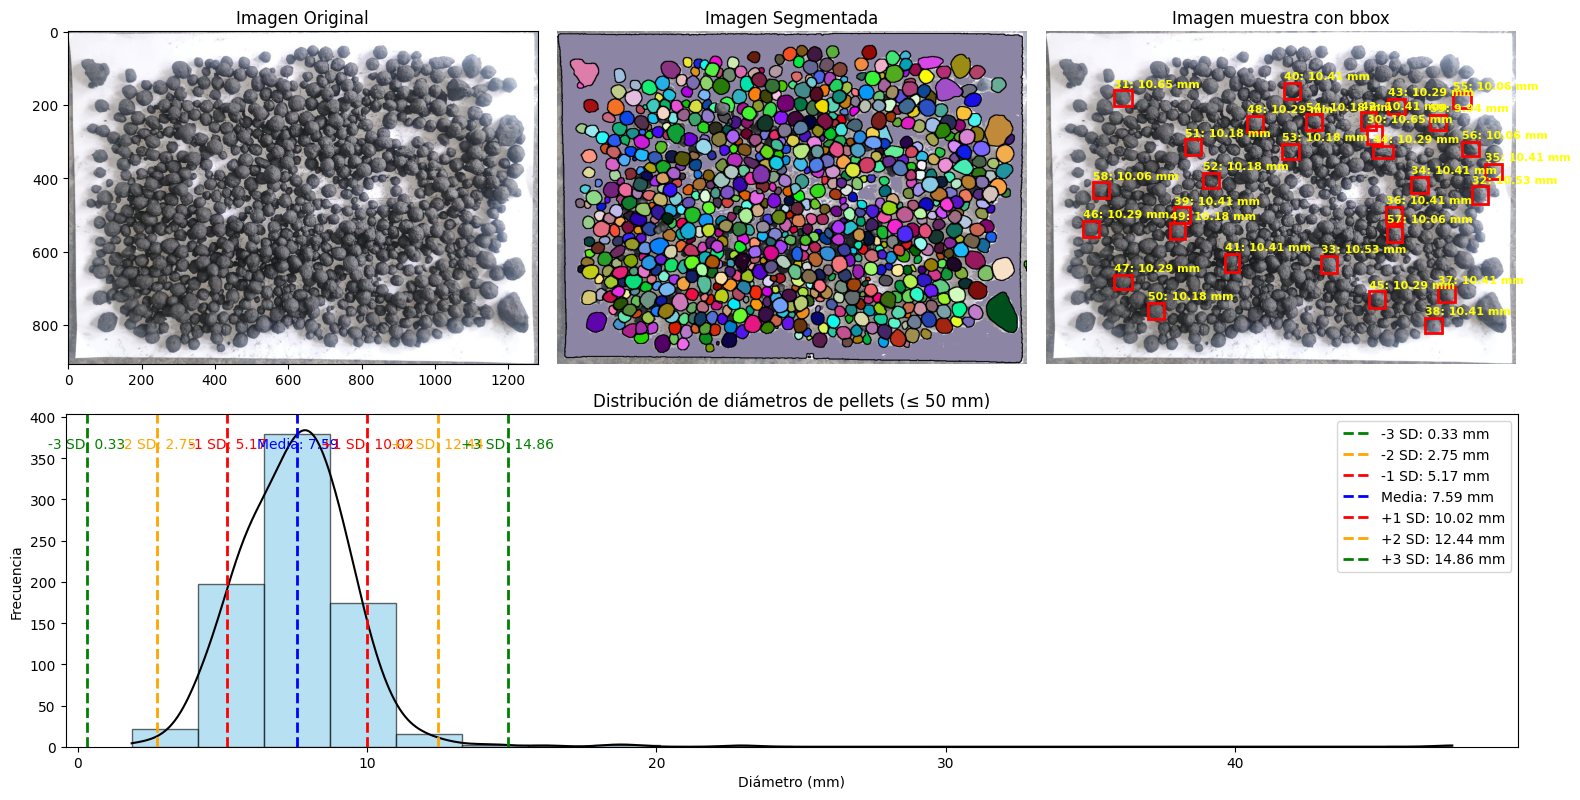

In [ ]:
#@title PROCESAMIENTO Y PLOTS

def show_anns(image, anns, borders=True):
    if len(anns) == 0:
        return image
    sorted_anns = sorted(anns, key=lambda x: x['area'], reverse=True)
    img = np.array(image)
    for ann in sorted_anns:
        m = ann['segmentation']
        color_mask = np.random.random(3) * 255
        img[m] = color_mask
        if borders:
            contours, _ = cv2.findContours(m.astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
            cv2.drawContours(img, contours, -1, (0, 0, 0), 2)
    return img

def get_bounding_boxes_and_diameters(masks):
    bboxes = []
    diameters = []
    for mask in masks:
        props = regionprops(mask['segmentation'].astype(int))
        for prop in props:
            minr, minc, maxr, maxc = prop.bbox
            width = maxc - minc
            height = maxr - minr
            diameter = (width + height) / 2
            bboxes.append((minc, minr, width, height))
            diameters.append(diameter)
    return bboxes, diameters

bboxes, diameters = get_bounding_boxes_and_diameters(masks)

#REFERENCIA
reference_mm = 253.5
pixels_per_mm = max(diameters) / reference_mm

diameters_mm = [d / pixels_per_mm for d in diameters]

sorted_data = sorted(zip(bboxes, diameters_mm), key=lambda x: x[1], reverse=True)
sorted_bboxes, sorted_diameters = zip(*sorted_data)

filtered_diameters = [d for d in sorted_diameters if d <= 50]

bbox_muestra = sorted_bboxes[30:60]
diameters_muestra_mm = sorted_diameters[30:60]

fig = plt.figure(figsize=(16, 8))
gs = gridspec.GridSpec(2, 3, height_ratios=[3, 3], width_ratios=[1.5, 1.5, 1.5])

#POSICIONAMIENTO DE IMAGENES
#PRIMERA IMAGEN
ax1 = fig.add_subplot(gs[0, 0])
ax1.imshow(image_1_np)
ax1.set_title('Imagen Original')
ax1.axis('on')

#SEFUNDA IMAGEN
ax2 = fig.add_subplot(gs[0, 1])
segmented_image = show_anns(image_1_np, masks)
ax2.imshow(segmented_image)
ax2.set_title('Imagen Segmentada')
ax2.axis('off')

#TERCERA IMAGEN
ax3 = fig.add_subplot(gs[0, 2])
ax3.imshow(image_1_np)
for idx, (bbox, diameter_mm) in enumerate(zip(bbox_muestra, diameters_muestra_mm), start=30):
    minc, minr, width, height = bbox
    rect = plt.Rectangle((minc, minr), width, height, fill=False, edgecolor='red', linewidth=2)
    ax3.add_patch(rect)
    ax3.text(minc, minr - 10, f'{idx}: {diameter_mm:.2f} mm', color='yellow', fontsize=8, weight='bold')
ax3.set_title('Imagen muestra con bbox')
ax3.axis('off')

#CUARTA IMAGEN
ax4 = fig.add_subplot(gs[1, :])

n, bins, patches = ax4.hist(filtered_diameters, bins=20, density=False, alpha=0.6, color='skyblue', edgecolor='black')

density = gaussian_kde(filtered_diameters)
density.covariance_factor = lambda : .25
density._compute_covariance()
x = np.linspace(min(filtered_diameters), max(filtered_diameters), 1000)
ax4.plot(x, density(x) * len(filtered_diameters) * np.diff(bins)[0], color='black')  # Ajustar la curva de densidad

mean_diameter = np.mean(filtered_diameters)
std_diameter = np.std(filtered_diameters)

colors = ['green', 'orange', 'red', 'blue', 'red', 'orange', 'green']
labels = ['-3 SD', '-2 SD', '-1 SD', 'Media', '+1 SD', '+2 SD', '+3 SD']
for i, (color, label) in enumerate(zip(colors, labels)):
    position = mean_diameter + (i - 3) * std_diameter
    ax4.axvline(position, color=color, linestyle='dashed', linewidth=2,
                label=f'{label}: {position:.2f} mm')
    ax4.text(position, ax4.get_ylim()[1]*0.9, f'{label}: {position:.2f}', color=color, ha='center')

ax4.set_xlabel('Diámetro (mm)')
ax4.set_ylabel('Frecuencia')
ax4.set_title('Distribución de diámetros de pellets (≤ 50 mm)')
ax4.legend()

plt.tight_layout()
plt.show()



N = 4 #CORREGIR
Fecha = datetime.now().date()

display(HTML(f'<span style="font-weight: bold; font-size: 1.5em; color: black;">Desviación_estandar: {std_diameter}</span>'))
display(HTML(f'<span style="font-weight: bold; font-size: 1.5em; color: black;">Media: {mean_diameter}</span>'))
display(HTML(f'<span style="font-weight: bold; font-size: 1.5em; color: black;">Fecha: {Fecha}</span>'))
display(HTML(f'<span style="font-weight: bold; font-size: 1.5em; color: black;">Horno: {N}</span>'))

##**PROCESANDO IMAGENES DESDE GOOGLE DRIVE**

In [ ]:
#@title Montaje de drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#@title Carga de imagenes y funciones

start_date = pd.to_datetime('09-10-24', format='%d-%m-%y')
end_date = pd.to_datetime('09-10-24', format='%d-%m-%y')

# RUTA DE DRIVE PARA LECTURA DE IMAGENES

base_path = '/content/drive/MyDrive/Pellets colección'


#MODELO CON HIPERPARAMETROS AJUSTADOS
sam2_checkpoint = "/content/segment-anything-2/checkpoints/sam2.1_hiera_large.pt"
model_cfg = "configs/sam2.1/sam2.1_hiera_l.yaml"
sam2 = build_sam2(model_cfg, sam2_checkpoint, device='cuda', apply_postprocessing=False, strict=False)
mask_generator = SAM2AutomaticMaskGenerator(sam2,
                                            pred_iou_thresh=0.8,
                                            stability_score_thresh=0.5,
                                            stability_score_offset=0.95,
                                            points_per_batch=128,
                                            box_nms_thresh=0.2,
                                            crop_nms_thresh=0.2,
                                            crop_n_layers=2,
                                            crop_n_points_downscale_factor=1)

# FUNCION PARA OBTENER BBOX Y DIAMETROS
def get_bounding_boxes_and_diameters(masks):
    bboxes = []
    diameters = []
    for mask in masks:
        props = regionprops(mask['segmentation'].astype(int))
        for prop in props:
            minr, minc, maxr, maxc = prop.bbox
            width = maxc - minc
            height = maxr - minr
            diameter = (width + height) / 2
            bboxes.append((minc, minr, width, height))
            diameters.append(diameter)
    return bboxes, diameters

def process_image(image_path):
    image = Image.open(image_path).convert("RGB")
    image_np = np.array(image)

    masks = mask_generator.generate(image_np)

    bboxes, diameters = get_bounding_boxes_and_diameters(masks)

    # FACTOR DE CONVERSION
    reference_mm = 253.5
    pixels_per_mm = max(diameters) / reference_mm
    diameters_mm = [d / pixels_per_mm for d in diameters]

    # FILTRADO DE DIAMETROS PARA ELIMINAR LA HOJA
    filtered_diameters = [d for d in diameters_mm if d <= 50]

    return filtered_diameters

# FUNCION PARA PROCESAR IMAGENES DESDE GOOGLE DRIVE
def process_images_from_drive(base_path, start_date=None, end_date = None):
    # Diccionario para almacenar los datos
    data = {'Fecha': [], 'Hora': [], 'H1': [], 'H2': [], 'H3': [], 'H4': []}

    for folder_name in sorted(os.listdir(base_path)):
        folder_path = os.path.join(base_path, folder_name)
        folder_date = pd.to_datetime(folder_name, format='%d-%m-%y', errors='coerce')

        if os.path.isdir(folder_path) and (start_date is None or folder_date >= start_date) and (end_date is None or folder_date <= end_date):
            for hour_folder in sorted(os.listdir(folder_path)):
                hour_path = os.path.join(folder_path, hour_folder)

                # DICCIONARIO
                hornos_diameters = {'H1': [], 'H2': [], 'H3': [], 'H4': []}

                for image_name in os.listdir(hour_path):
                    image_path = os.path.join(hour_path, image_name)

                    # EXTRAER NUMERO DE HORNO
                    horno_key = image_name.split('_')[1]

                    diameters = process_image(image_path)

                    hornos_diameters[horno_key].extend(diameters)

                # AGREGAR AL DF
                max_len = max(len(hornos_diameters['H1']), len(hornos_diameters['H2']), len(hornos_diameters['H3']), len(hornos_diameters['H4']))

                # RELLENAR VALORES VACÍOS CON NAN
                for horno in hornos_diameters:
                    hornos_diameters[horno] += [None] * (max_len - len(hornos_diameters[horno]))

                for i in range(max_len):
                    data['Fecha'].append(folder_name)
                    data['Hora'].append(hour_folder)
                    data['H1'].append(hornos_diameters['H1'][i])
                    data['H2'].append(hornos_diameters['H2'][i])
                    data['H3'].append(hornos_diameters['H3'][i])
                    data['H4'].append(hornos_diameters['H4'][i])

    return pd.DataFrame(data)

# RUTA DEL DF EXISTENTE O CREAR UNO PARA GUARDAR LOS DATOS
csv_path = '/content/drive/My Drive/pellets_data.csv'

try:
    df_results = pd.read_csv(csv_path)
except FileNotFoundError:
    df_results = pd.DataFrame(columns=['Fecha', 'Hora', 'H1', 'H2', 'H3', 'H4'])

df_new_data = process_images_from_drive(base_path, start_date=start_date,end_date=end_date)
df_results = pd.concat([df_results, df_new_data], ignore_index=True)
df_results.to_csv(csv_path, index=False)

##**ANALISIS DE RESULTADOS**

In [ ]:
#@title Importación solo para los datos preprocesados y almacenados en drive
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
#@title Carga de data
df = pd.read_csv("/content/drive/MyDrive/pellets_data.csv")

df["Fecha"] = pd.to_datetime(df['Fecha'], errors='coerce')

<ipython-input-14-5600a8c9ede2>:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Fecha"] = pd.to_datetime(df['Fecha'], errors='coerce')


<ipython-input-9-13feb8777a1b>:31: UserWarning: The palette list has more values (9) than needed (4), which may not be intended.
  sns.boxplot(x='Fecha', y='Horno_Valor', hue='Horno', data=df_total, palette=palette,


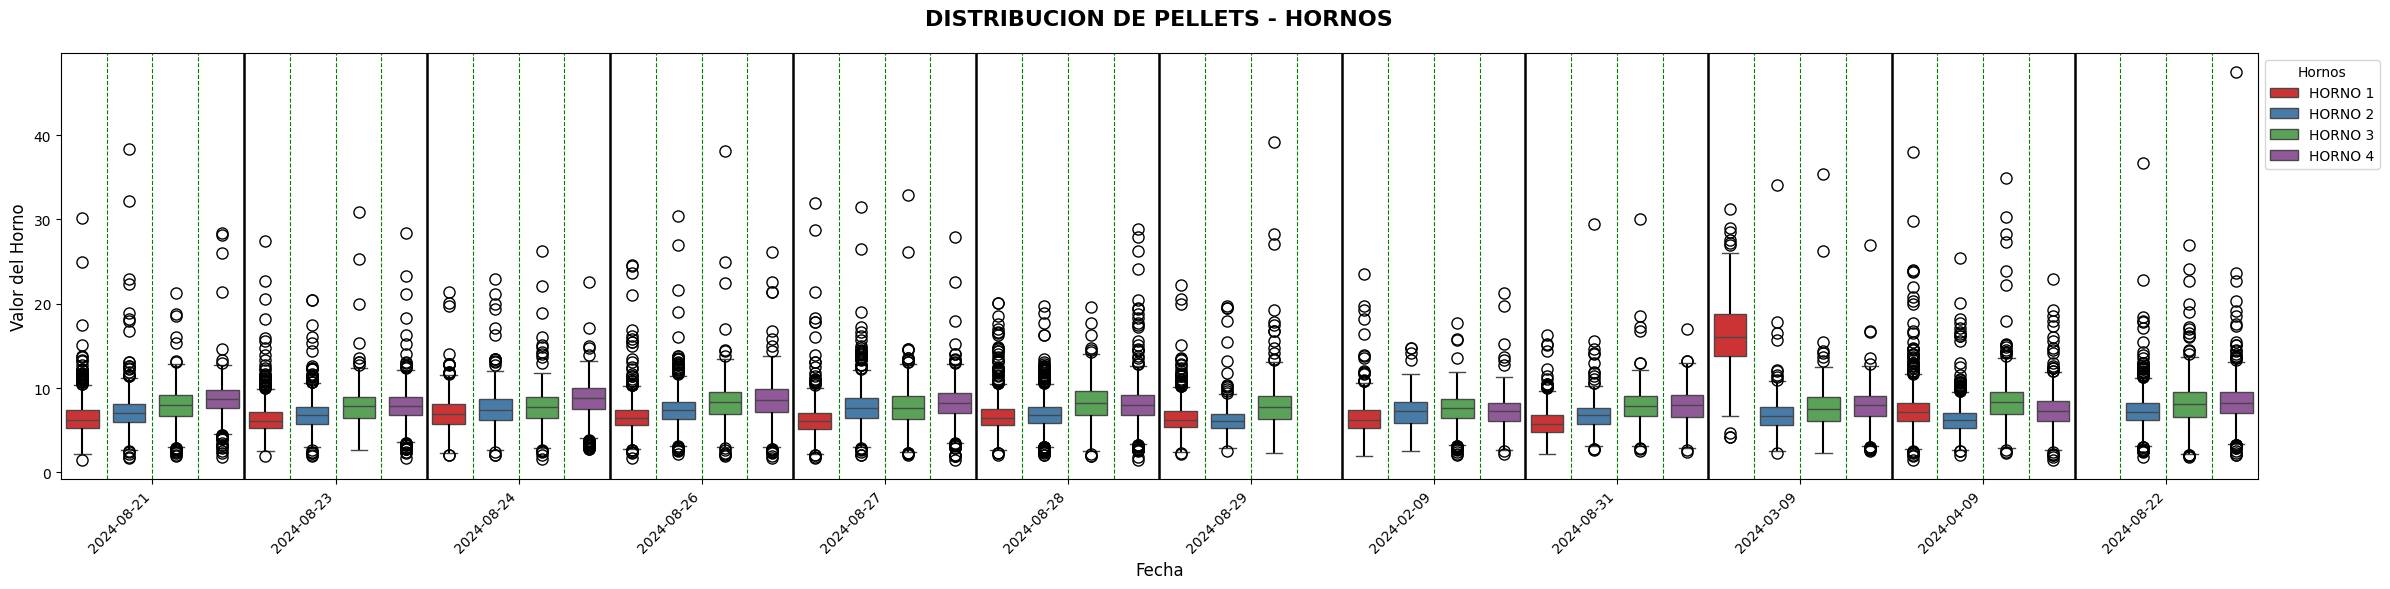

In [ ]:
#@title Plots
df_h1 = df[['H1',"Fecha"]]
df_h2 = df[['H2',"Fecha"]]
df_h3 = df[['H3',"Fecha"]]
df_h4 = df[['H4',"Fecha"]]

df_h1_limpio = df_h1.dropna(subset = ["H1"])
df_h2_limpio = df_h2.dropna(subset = ["H2"])
df_h3_limpio = df_h3.dropna(subset = ["H3"])
df_h4_limpio = df_h4.dropna(subset = ["H4"])

df_h1_limpio = df_h1_limpio.rename(columns={'H1': 'Horno_Valor'})
df_h2_limpio = df_h2_limpio.rename(columns={'H2': 'Horno_Valor'})
df_h3_limpio = df_h3_limpio.rename(columns={'H3': 'Horno_Valor'})
df_h4_limpio = df_h4_limpio.rename(columns={'H4': 'Horno_Valor'})

df_h1_limpio['Horno'] = 'HORNO 1'
df_h2_limpio['Horno'] = 'HORNO 2'
df_h3_limpio['Horno'] = 'HORNO 3'
df_h4_limpio['Horno'] = 'HORNO 4'

df_total = pd.concat([df_h1_limpio, df_h2_limpio, df_h3_limpio, df_h4_limpio])

# Eliminar posibles duplicados en las filas después de concatenar
df_total = df_total.reset_index(drop=True)

# BOXPLOT
plt.figure(figsize=(24, 6))
palette = sns.color_palette('Set1')

#CENTRADO DE CAJA
sns.boxplot(x='Fecha', y='Horno_Valor', hue='Horno', data=df_total, palette=palette,
            gap=0.3,
            width=1.02,
            flierprops=dict(marker='o', markersize=8, linestyle='none', markeredgecolor='black'),
            whiskerprops=dict(color='black', linewidth=1.5))
plt.xticks(rotation=45, ha='right')

#TITULO Y LEYENDA
plt.title('DISTRIBUCION DE PELLETS - HORNOS', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Fecha', fontsize=12)
plt.ylabel('Valor del Horno', fontsize=12)

plt.legend(title='Hornos', loc='upper left', bbox_to_anchor=(1, 1), fontsize=10)

#LINEAS DIVISORIAS
n_dates = len(df_total['Fecha'].unique())
n_hornos = len(df_total['Horno'].unique())

for i in range(n_dates):
    for j in range(1, n_hornos):
        plt.axvline(x=i + (j / n_hornos) - 0.5, color='green', linestyle='--', linewidth=0.8)
for i in range(n_dates - 1):
    plt.axvline(x=i + 0.5, color='black', linestyle='-', linewidth=1.8)

plt.tight_layout()
plt.show()
